In [1]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({'font.size': 12, 'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

RUN_DIR = Path('../../runs')
runs = {
    'C2 (B4, no RL)': RUN_DIR / '2026_04_22_sdpo_C2_B4_scores_only/metrics.jsonl',
    'C3 (SDPO)': RUN_DIR / '2026_04_22_sdpo_C3_sdpo_scores_only/metrics.jsonl',
    'C4 (Aggregate RL)': RUN_DIR / '2026_04_22_sdpo_C4_aggregate_scores_only/metrics.jsonl',
}
colors = {'C2 (B4, no RL)': '#2196F3', 'C3 (SDPO)': '#E91E63', 'C4 (Aggregate RL)': '#4CAF50'}

data = {}
for name, path in runs.items():
    data[name] = [json.loads(l) for l in open(path)]
    print(f'{name}: {len(data[name])} iters, final buf_max={data[name][-1]["reward/buffer_max"]:.3f}')

C2 (B4, no RL): 25 iters, final buf_max=0.855
C3 (SDPO): 19 iters, final buf_max=0.970
C4 (Aggregate RL): 27 iters, final buf_max=0.940


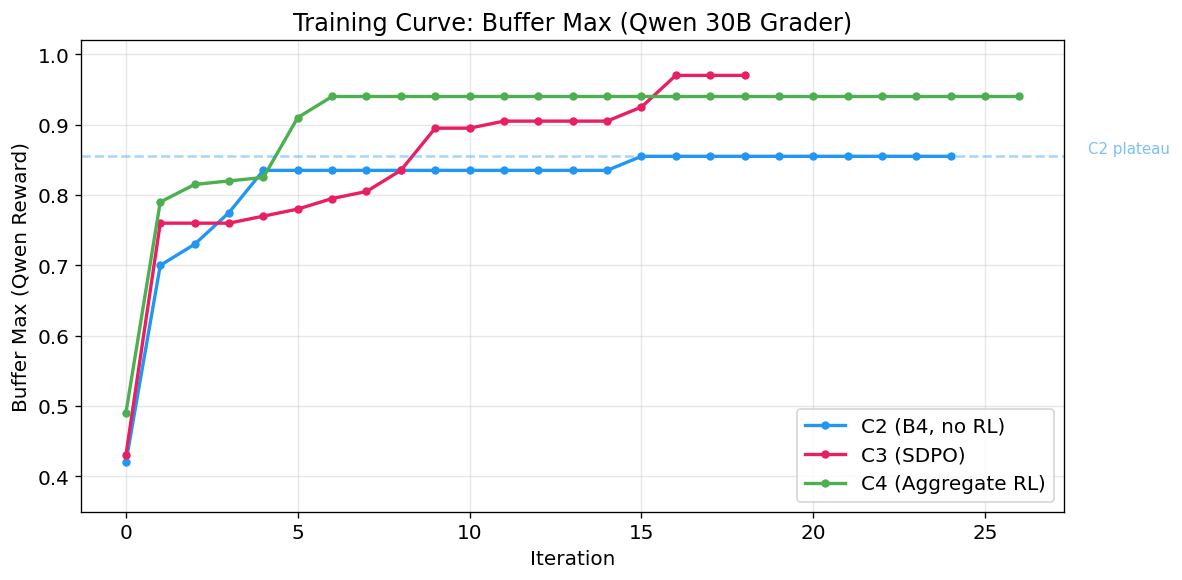

In [2]:
# === Figure 1: Buffer Max (Qwen reward) ===
fig, ax = plt.subplots(figsize=(10, 5))
for name, metrics in data.items():
    iters = [m['iter'] for m in metrics]
    buf_max = [m['reward/buffer_max'] for m in metrics]
    ax.plot(iters, buf_max, '-o', label=name, color=colors[name], markersize=4, linewidth=2)

ax.set_xlabel('Iteration')
ax.set_ylabel('Buffer Max (Qwen Reward)')
ax.set_title('Training Curve: Buffer Max (Qwen 30B Grader)')
ax.legend(loc='lower right')
ax.set_ylim(0.35, 1.02)
ax.axhline(y=0.855, color=colors['C2 (B4, no RL)'], linestyle='--', alpha=0.4, label='_nolegend_')
ax.text(28, 0.86, 'C2 plateau', color=colors['C2 (B4, no RL)'], alpha=0.6, fontsize=9)
plt.tight_layout()
plt.savefig('fig1_buffer_max.png', bbox_inches='tight')
plt.show()

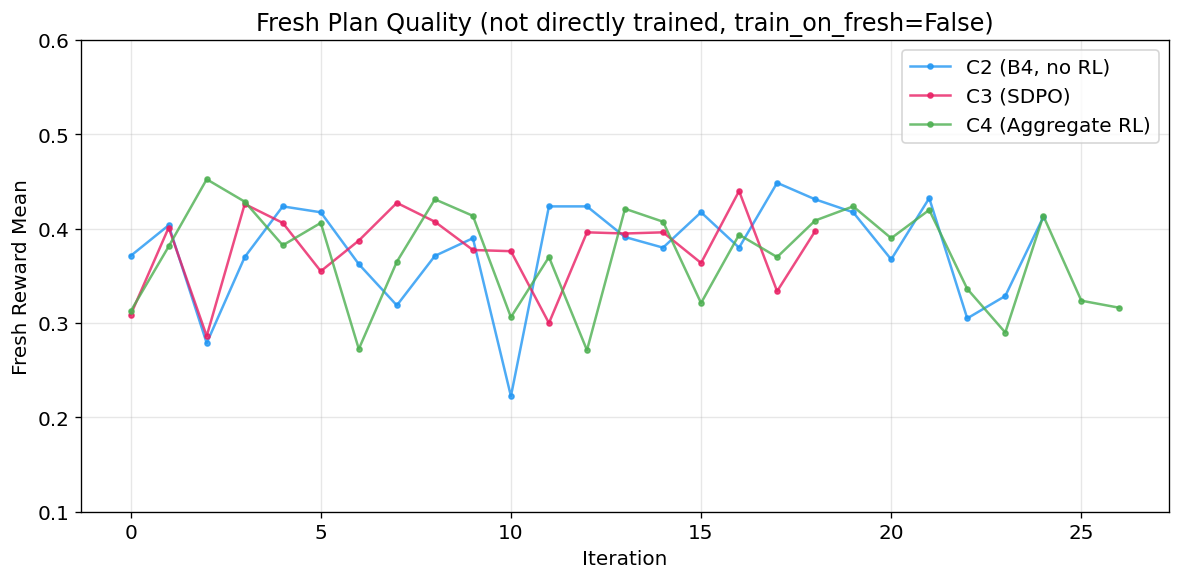

In [3]:
# === Figure 2: Fresh Reward Mean (generation quality, not revision) ===
fig, ax = plt.subplots(figsize=(10, 5))
for name, metrics in data.items():
    iters = [m['iter'] for m in metrics]
    fresh_r = [m['fresh/reward_mean'] for m in metrics]
    ax.plot(iters, fresh_r, '-o', label=name, color=colors[name], markersize=3, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Iteration')
ax.set_ylabel('Fresh Reward Mean')
ax.set_title('Fresh Plan Quality (not directly trained, train_on_fresh=False)')
ax.legend()
ax.set_ylim(0.1, 0.6)
plt.tight_layout()
plt.savefig('fig2_fresh_reward.png', bbox_inches='tight')
plt.show()

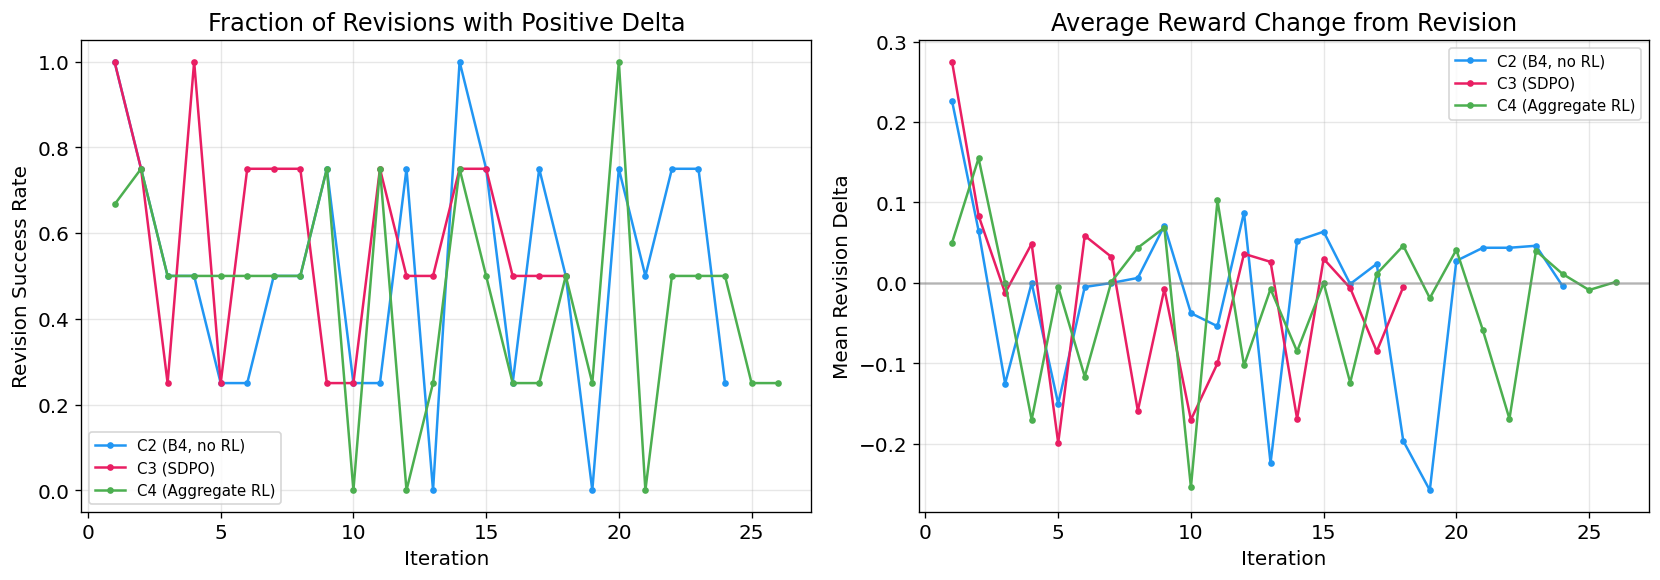

In [4]:
# === Figure 3: Revision Effectiveness ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3a: Revision success rate
ax = axes[0]
for name, metrics in data.items():
    iters = [m['iter'] for m in metrics if m['revise/count'] > 0]
    success = [m['revise/n_positive'] / m['revise/count'] for m in metrics if m['revise/count'] > 0]
    ax.plot(iters, success, '-o', label=name, color=colors[name], markersize=3, linewidth=1.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Revision Success Rate')
ax.set_title('Fraction of Revisions with Positive Delta')
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.05)

# 3b: Mean revision delta
ax = axes[1]
for name, metrics in data.items():
    iters = [m['iter'] for m in metrics if m['revise/count'] > 0]
    deltas = [m['revise/mean_delta'] for m in metrics if m['revise/count'] > 0]
    ax.plot(iters, deltas, '-o', label=name, color=colors[name], markersize=3, linewidth=1.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean Revision Delta')
ax.set_title('Average Reward Change from Revision')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig3_revision_effectiveness.png', bbox_inches='tight')
plt.show()

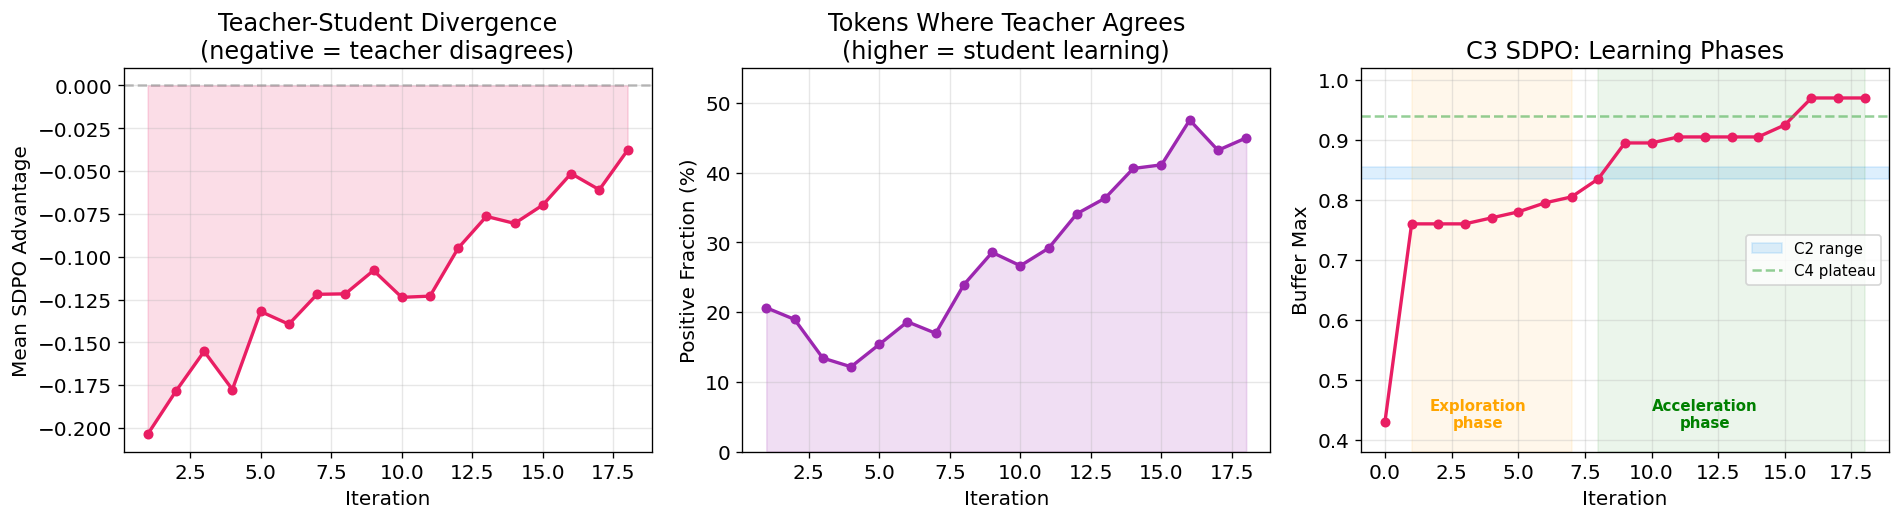

In [5]:
# === Figure 4: SDPO-specific metrics (C3 only) ===
c3 = data['C3 (SDPO)']
c3_sdpo = [m for m in c3 if m.get('sdpo/n_datums', 0) > 0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 4a: SDPO mean advantage
ax = axes[0]
iters = [m['iter'] for m in c3_sdpo]
advs = [m['sdpo/mean_advantage'] for m in c3_sdpo]
ax.plot(iters, advs, '-o', color='#E91E63', markersize=5, linewidth=2)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean SDPO Advantage')
ax.set_title('Teacher-Student Divergence\n(negative = teacher disagrees)')
ax.fill_between(iters, advs, 0, alpha=0.15, color='#E91E63')

# 4b: Positive fraction
ax = axes[1]
pos = [m['sdpo/positive_frac'] * 100 for m in c3_sdpo]
ax.plot(iters, pos, '-o', color='#9C27B0', markersize=5, linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Positive Fraction (%)')
ax.set_title('Tokens Where Teacher Agrees\n(higher = student learning)')
ax.set_ylim(0, 55)
ax.fill_between(iters, pos, alpha=0.15, color='#9C27B0')

# 4c: buf_max with phase annotations
ax = axes[2]
all_iters = [m['iter'] for m in c3]
all_buf = [m['reward/buffer_max'] for m in c3]
ax.plot(all_iters, all_buf, '-o', color='#E91E63', markersize=5, linewidth=2)
ax.axhspan(0.835, 0.855, alpha=0.15, color='#2196F3', label='C2 range')
ax.axhline(y=0.940, color='#4CAF50', linestyle='--', alpha=0.6, label='C4 plateau')
ax.axvspan(1, 7, alpha=0.08, color='orange')
ax.axvspan(8, max(all_iters), alpha=0.08, color='green')
ax.text(3.5, 0.42, 'Exploration\nphase', ha='center', fontsize=9, color='orange', fontweight='bold')
ax.text(12, 0.42, 'Acceleration\nphase', ha='center', fontsize=9, color='green', fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('Buffer Max')
ax.set_title('C3 SDPO: Learning Phases')
ax.legend(fontsize=9, loc='center right')
ax.set_ylim(0.38, 1.02)

plt.tight_layout()
plt.savefig('fig4_sdpo_metrics.png', bbox_inches='tight')
plt.show()

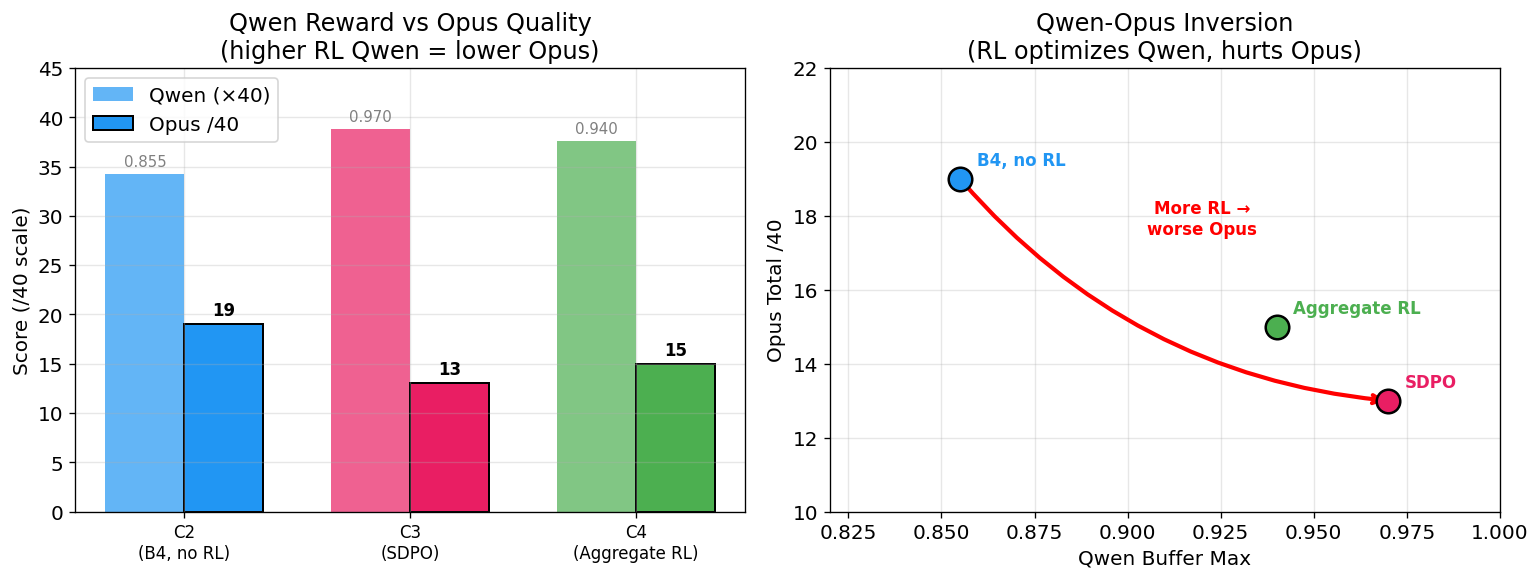

In [6]:
# === Figure 5: Qwen vs Opus (the inversion) ===
opus = [
    {'tag': 'C2 (B4, no RL)', 'qwen': 0.855, 'opus': 19},
    {'tag': 'C3 (SDPO)', 'qwen': 0.970, 'opus': 13},
    {'tag': 'C4 (Aggregate RL)', 'qwen': 0.940, 'opus': 15},
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 5a: Bar comparison
ax = axes[0]
tags = [o['tag'] for o in opus]
x = np.arange(len(tags))
w = 0.35
bars1 = ax.bar(x - w/2, [o['qwen'] * 40 for o in opus], w, label='Qwen (×40)', color=['#2196F3', '#E91E63', '#4CAF50'], alpha=0.7)
bars2 = ax.bar(x + w/2, [o['opus'] for o in opus], w, label='Opus /40', color=['#2196F3', '#E91E63', '#4CAF50'], alpha=1.0, edgecolor='black', linewidth=1.2)

for bar, val in zip(bars1, [o['qwen'] for o in opus]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5, f'{val:.3f}', ha='center', va='bottom', fontsize=9, color='gray')
for bar, val in zip(bars2, [o['opus'] for o in opus]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5, f'{val}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Score (/40 scale)')
ax.set_title('Qwen Reward vs Opus Quality\n(higher RL Qwen = lower Opus)')
ax.set_xticks(x)
ax.set_xticklabels([t.replace(' (', '\n(') for t in tags], fontsize=10)
ax.legend()
ax.set_ylim(0, 45)

# 5b: Scatter with arrow
ax = axes[1]
for o in opus:
    c = colors[o['tag']]
    ax.scatter(o['qwen'], o['opus'], s=200, color=c, zorder=5, edgecolors='black', linewidth=1.5)
    ax.annotate(o['tag'].split('(')[1].rstrip(')'), (o['qwen'], o['opus']),
                textcoords="offset points", xytext=(10, 8), fontsize=10, color=c, fontweight='bold')

ax.annotate('', xy=(0.970, 13), xytext=(0.855, 19),
            arrowprops=dict(arrowstyle='->', color='red', lw=2.5, connectionstyle='arc3,rad=0.2'))
ax.text(0.92, 17.5, 'More RL →\nworse Opus', color='red', fontsize=10, ha='center', fontweight='bold')

ax.set_xlabel('Qwen Buffer Max')
ax.set_ylabel('Opus Total /40')
ax.set_title('Qwen-Opus Inversion\n(RL optimizes Qwen, hurts Opus)')
ax.set_xlim(0.82, 1.0)
ax.set_ylim(10, 22)

plt.tight_layout()
plt.savefig('fig5_qwen_vs_opus.png', bbox_inches='tight')
plt.show()

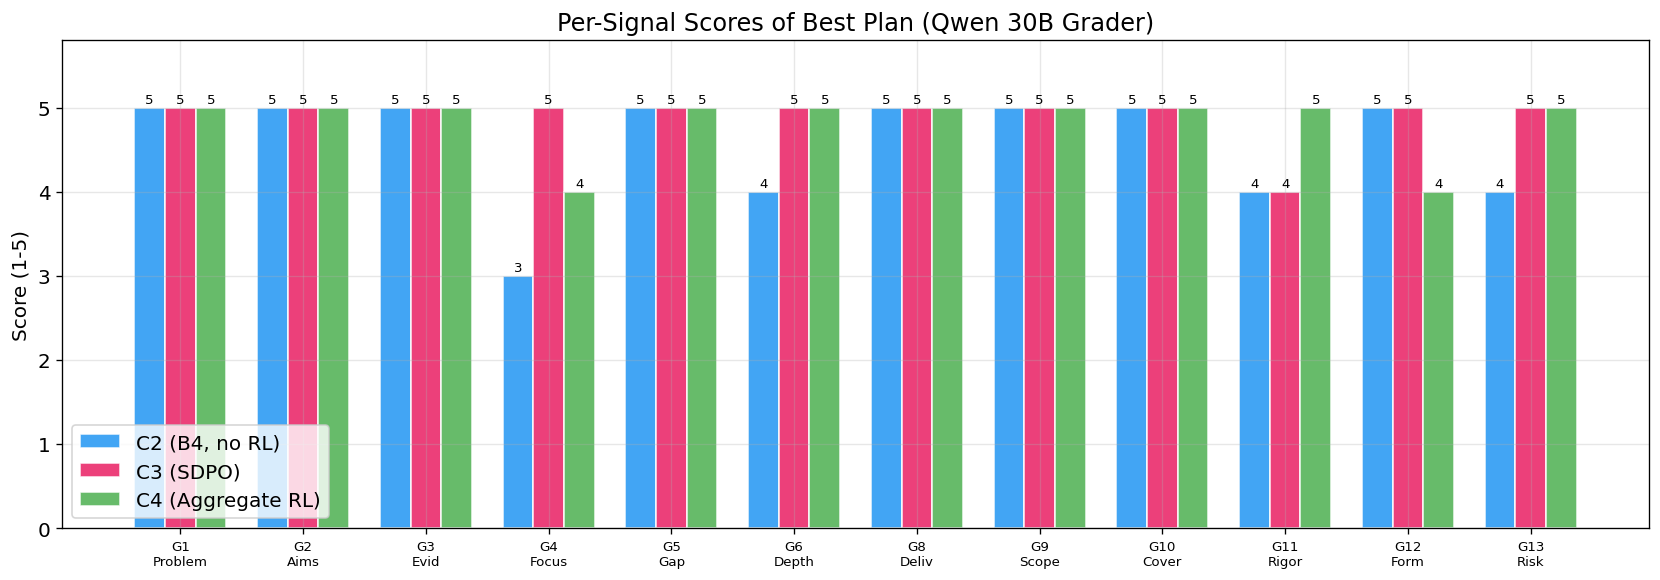

In [7]:
# === Figure 6: Per-signal comparison (best plan from each run) ===
signal_ids = ['G1_problem_specificity', 'G2_specific_aims', 'G3_technical_evidence',
              'G4_focus', 'G5_gap_identification', 'G6_reasoning_depth',
              'G8_deliverable_clarity', 'G9_scope_feasibility', 'G10_approach_coverage',
              'G11_evidence_rigor', 'G12_formalism', 'G13_risk_awareness']
signal_short = ['G1\nProblem', 'G2\nAims', 'G3\nEvid', 'G4\nFocus', 'G5\nGap',
                'G6\nDepth', 'G8\nDeliv', 'G9\nScope', 'G10\nCover', 'G11\nRigor',
                'G12\nForm', 'G13\nRisk']

best_signals = {}
for tag, buf_path in [
    ('C2 (B4, no RL)', RUN_DIR / '2026_04_22_sdpo_C2_B4_scores_only/buffer.jsonl'),
    ('C3 (SDPO)', RUN_DIR / '2026_04_22_sdpo_C3_sdpo_scores_only/buffer.jsonl'),
    ('C4 (Aggregate RL)', RUN_DIR / '2026_04_22_sdpo_C4_aggregate_scores_only/buffer.jsonl'),
]:
    best = None
    for line in open(buf_path):
        e = json.loads(line)
        if e.get('hard_gate_passed') and (best is None or e['aggregate_reward'] > best['aggregate_reward']):
            best = e
    best_signals[tag] = {sid: best['signal_vector'].get(sid, 0) for sid in signal_ids}

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(signal_ids))
w = 0.25
for i, (name, sigs) in enumerate(best_signals.items()):
    vals = [sigs[sid] for sid in signal_ids]
    bars = ax.bar(x + (i - 1) * w, vals, w, label=name, color=colors[name], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, str(v), ha='center', fontsize=8)

ax.set_ylabel('Score (1-5)')
ax.set_title('Per-Signal Scores of Best Plan (Qwen 30B Grader)')
ax.set_xticks(x)
ax.set_xticklabels(signal_short, fontsize=8)
ax.legend()
ax.set_ylim(0, 5.8)
plt.tight_layout()
plt.savefig('fig6_per_signal.png', bbox_inches='tight')
plt.show()

In [8]:
# === Summary Table ===
print("=" * 80)
print("SDPO Experiment Summary (2026-04-22)")
print("=" * 80)
print()
print("Training Metrics (Qwen 30B grader):")
print(f"  {'Run':<25s} {'Iters':>6s} {'buf_max':>8s} {'fresh_r':>8s} {'rev_pos':>8s}")
print(f"  {'-'*25} {'-'*6} {'-'*8} {'-'*8} {'-'*8}")
for name, metrics in data.items():
    last = metrics[-1]
    rev_with_data = [m for m in metrics if m['revise/count'] > 0]
    avg_rev = np.mean([m['revise/n_positive']/m['revise/count'] for m in rev_with_data]) if rev_with_data else 0
    print(f"  {name:<25s} {len(metrics):>6d} {last['reward/buffer_max']:>8.3f} {np.mean([m['fresh/reward_mean'] for m in metrics]):>8.3f} {avg_rev:>7.1%}")

print()
print("Opus Eval (Opus 4.7, /40):")
print(f"  {'Run':<25s} {'Qwen':>6s} {'Opus':>6s} {'D':>3s} {'M':>3s} {'F':>3s} {'G':>3s}")
print(f"  {'-'*25} {'-'*6} {'-'*6} {'-'*3} {'-'*3} {'-'*3} {'-'*3}")
for o in [
    {'tag': 'C2 (B4, no RL)', 'qwen': 0.855, 'opus': 19, 'D': 5, 'M': 5, 'F': 5, 'G': 4},
    {'tag': 'C4 (Aggregate RL)', 'qwen': 0.940, 'opus': 15, 'D': 4, 'M': 3, 'F': 4, 'G': 4},
    {'tag': 'C3 (SDPO)', 'qwen': 0.970, 'opus': 13, 'D': 4, 'M': 3, 'F': 4, 'G': 2},
    {'tag': 'Reference (prev)', 'qwen': None, 'opus': 34, 'D': 9, 'M': 9, 'F': 8, 'G': 8},
]:
    qwen_str = f"{o['qwen']:.3f}" if o['qwen'] else "  ---"
    print(f"  {o['tag']:<25s} {qwen_str:>6s} {o['opus']:>6d} {o['D']:>3d} {o['M']:>3d} {o['F']:>3d} {o['G']:>3d}")

print()
print("Key Findings:")
print("  1. SDPO achieves highest Qwen (0.970) but lowest Opus (13/40) = Goodhart")
print("  2. Qwen-Opus inversion: RL rank C3>C4>C2, Opus rank C2>C4>C3")
print("  3. SDPO learning dynamics clear: pos_frac 12%->48% (student learning)")
print("  4. Dense per-token credit = more precise Goodharting, not better quality")
print("  5. B4 (no RL) remains best on Opus, consistent with all prior experiments")

SDPO Experiment Summary (2026-04-22)

Training Metrics (Qwen 30B grader):
  Run                        Iters  buf_max  fresh_r  rev_pos
  ------------------------- ------ -------- -------- --------
  C2 (B4, no RL)                25    0.855    0.380   52.1%
  C3 (SDPO)                     19    0.970    0.378   59.7%
  C4 (Aggregate RL)             27    0.940    0.371   44.9%

Opus Eval (Opus 4.7, /40):
  Run                         Qwen   Opus   D   M   F   G
  ------------------------- ------ ------ --- --- --- ---
  C2 (B4, no RL)             0.855     19   5   5   5   4
  C4 (Aggregate RL)          0.940     15   4   3   4   4
  C3 (SDPO)                  0.970     13   4   3   4   2
  Reference (prev)             ---     34   9   9   8   8

Key Findings:
  1. SDPO achieves highest Qwen (0.970) but lowest Opus (13/40) = Goodhart
  2. Qwen-Opus inversion: RL rank C3>C4>C2, Opus rank C2>C4>C3
  3. SDPO learning dynamics clear: pos_frac 12%->48% (student learning)
  4. Dense per-tok